# Results Loader and Plots Comparison for all Models

In [1]:
from pathlib import Path

import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.utils import load_results_from_dir, results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TARGET_MODE = cfg.runtime.target_mode
SAVE = True
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

2025-09-20 08:20:10,108 - INFO - src.utils - Global random seed set to 42


In [3]:
results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

(5, ['cnn', 'linreg', 'lstm', 'random_forest', 'xgboost'])

In [4]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

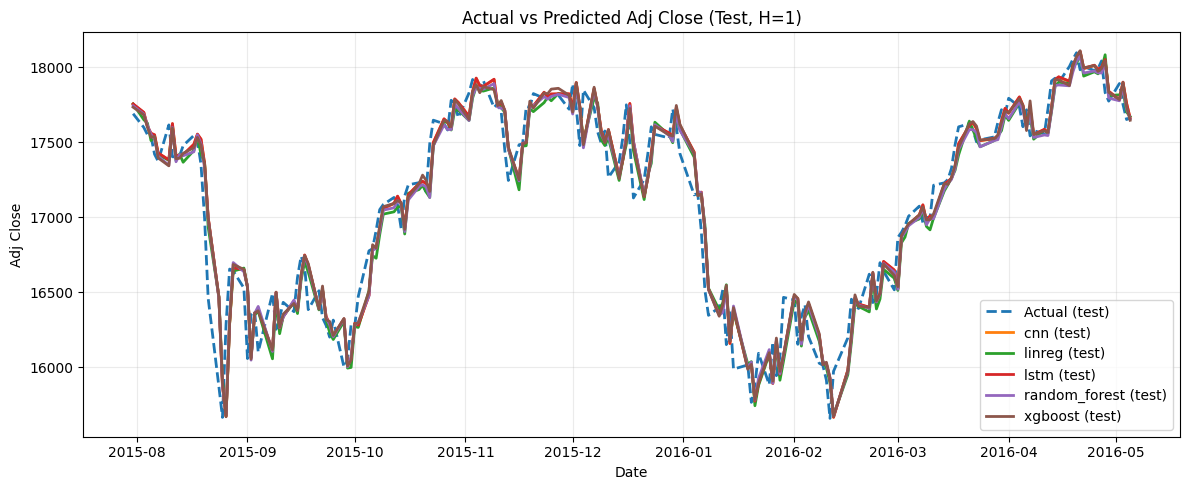

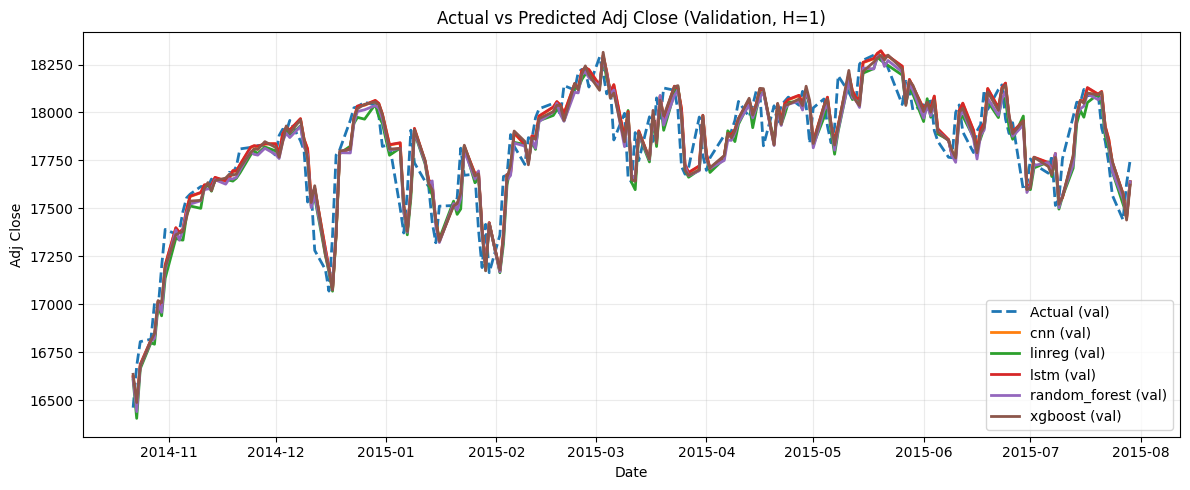

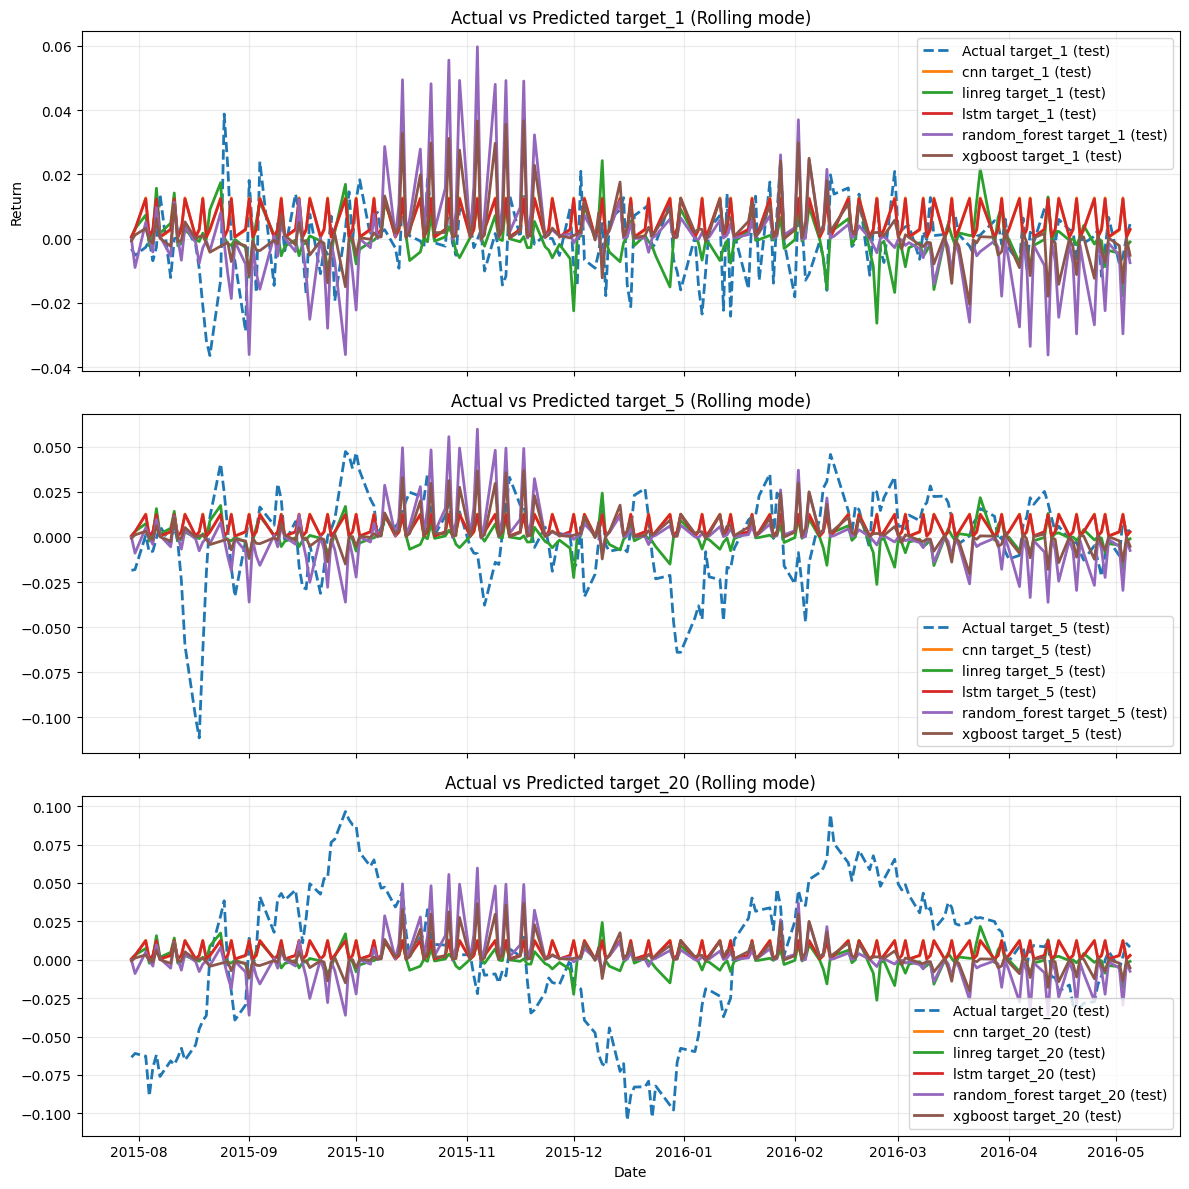

In [5]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_actual_vs_predicted_adj_close_test.png", save=SAVE)
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_actual_vs_predicted_adj_close_val.png", save=SAVE)
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_returns.png", phase="test", target_mode=TARGET_MODE, save=SAVE)
if TARGET_MODE == "step":
    plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_forecast.png", save=SAVE)
    plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_forecast_diagnostics.png", save=SAVE)

In [6]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,filters,kernel_size,dense_units,dropout,lr,epochs,batch_size,weight_decay,random_state,...,reg_lambda,gamma,max_bin,grow_policy,objective,eval_metric,subsample,colsample_bytree,tree_method,max_leaves
0,cnn,64.0,2.0,64.0,0.285774,0.001329,60.0,16.0,0.000009,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,linreg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lstm,NaN,NaN,64.0,0.178820,0.001597,60.0,16.0,0.000013,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,...,1.449503,0.382626,128.0,depthwise,reg:absoluteerror,mae,0.824255,0.819524,hist,0.0


In [7]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,cnn,0.020739,0.000941,0.030682,-0.033926,0.552496
1,linreg,0.021506,0.000961,0.030998,-0.055316,0.478485
2,lstm,0.020728,0.000940,0.030660,-0.032437,0.552496
3,random_forest,0.022545,0.000977,0.031259,-0.073148,0.549053
4,xgboost,0.020634,0.000849,0.029141,0.067351,0.576592
